# Eyes on the Sky: starter notebook

Practice challenge 02 of Canada's Defence Tech Hackathon. This notebook explains the data, builds a simple baseline for all three tasks, checks it on a validation day and writes a submission file. It runs top to bottom in well under a minute.

Everything here is synthetic: the tracks are simulated, and the flight authorizations and operators are fictional.

## 1. The challenge in plain language

Three sites near Edmonton are watched for seven days: Edmonton International Airport (YEG), the Genesee Generating Station (GEN) and the Royal Alexandra Hospital heliport (RAH). Each site has a circular **alert zone**: 3 km around the airport, 1 km around the other two. The sensors report **tracks**, meaning objects followed over time. You get labels for the first five days; the last two days are the test.

**What each sensor tells you.** The radar measures where each object is (range, position and height), how fast it moves and its radar cross-section (RCS), which says how big the echo is. At short range it also picks up micro-Doppler, the fast flicker that spinning propellers or flapping wings add to the echo. Two RF direction finders listen for the radio link between a drone and its controller, and each one reports the compass bearing to the transmitter; because the pilot holds the controller, the two bearings cross near the pilot. ADS-B is a position broadcast that most aeroplanes and many helicopters send, so a track with ADS-B is almost certainly manned. A microphone array hears loud things within a few hundred metres, and a camera with an onboard classifier gives a label and a confidence for things within about 1.5 km; it makes mistakes, more of them at night. Birds are the classic false alarm: they are small, slow and low and they wander, just like hobby drones, so position and echo size alone often can't tell them apart.

**Your three tasks**, answered for every test track:

| task | question | column(s) you submit | score |
|---|---|---|---|
| 2A What is it? | drone, bird, manned aircraft or something else? | `category`: `drone`, `bird`, `manned` or `other` | macro F1: the F1 of each class, averaged, so the few drones count as much as the many birds |
| 2B Raise the alarm? | is this an unauthorized drone inside the alert zone? | `alert`: 1 or 0 | F1 of the alerts (precision and recall shown too) |
| 2C Find the pilot | where is the person flying this drone? | `operator_lat`, `operator_lon` (may be blank) | median error in metres over radio-controlled drones; a blank counts as 5,000 m |

The right answer for 2B is `alert = 1` when the track is a drone, is **not** covered by a flight authorization, and enters its site's alert zone.

Your file is `submissions/tracks.csv` with the columns `track_id,category,alert,operator_lat,operator_lon`, one row per test track (a missing track counts as wrong on all three tasks). `score.py` in this folder does the scoring; you can call it from Python (as below) or from a terminal. Times are UTC; Edmonton is UTC−6 in September.

## 2. Load and inspect

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

from score import score_tracks  # the scorer in this folder

plt.rcParams.update({'figure.dpi': 80, 'savefig.dpi': 80})
pd.set_option('display.max_columns', 30)

In [2]:
tracks = pd.read_csv('sensor_tracks.csv', parse_dates=['timestamp'])
labels = pd.read_csv('labels_train/track_labels.csv', parse_dates=['start'])
sites = pd.read_csv('sites.csv').set_index('site_id')
sensors = pd.read_csv('sensors.csv')
auths = pd.read_csv('flight_authorizations.csv', parse_dates=['start_utc', 'end_utc'])

test_ids = sorted(set(tracks.track_id) - set(labels.track_id))
print(f'{len(tracks):,} sensor updates in {tracks.track_id.nunique():,} tracks')
print(f'{len(labels):,} labelled tracks (days 1-5) and {len(test_ids):,} test tracks (days 6-7)')
print('from', tracks.timestamp.min(), 'to', tracks.timestamp.max())
tracks.head()

76,718 sensor updates in 1,456 tracks
1,037 labelled tracks (days 1-5) and 419 test tracks (days 6-7)
from 2025-09-15 12:04:02+00:00 to 2025-09-22 05:42:02+00:00


,timestamp,site_id,track_id,lat,lon,alt_m,speed_mps,heading_deg,climb_mps,range_m,rcs_dbsm,doppler_mod_hz,rf_detected,rf_band_ghz,rf_rssi_dbm,rf1_bearing_deg,rf2_bearing_deg,adsb,adsb_icao,acoustic_dba,eo_label,eo_conf
0,2025-09-15 12:04:02+00:00,RAH,RAH-00145,53.556916,-113.471080,0.9,27.7,224.0,-0.3,1697.0,19.1,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
1,2025-09-15 12:04:04+00:00,RAH,RAH-00145,53.556621,-113.471776,-18.6,27.3,222.0,-0.3,1660.0,3.5,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
2,2025-09-15 12:04:06+00:00,RAH,RAH-00145,53.556185,-113.472007,13.6,27.3,226.0,0.3,1625.0,5.9,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
3,2025-09-15 12:04:08+00:00,RAH,RAH-00145,53.555803,-113.473068,2.2,28.1,221.0,-0.1,1592.0,11.9,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
4,2025-09-15 12:04:10+00:00,RAH,RAH-00145,53.555644,-113.473219,11.2,27.5,218.0,0.1,1559.0,13.6,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN


Each row is one radar update; updates come every 2 seconds while the radar holds the object. A blank cell means that sensor had nothing at that moment: no micro-Doppler beyond short range, no RF when there is no controller link, no camera label beyond about 1.5 km, and so on.

| columns | what they are |
|---|---|
| `lat`, `lon`, `alt_m` | radar position; altitude in metres (noisy, so readings below zero happen near the ground) |
| `speed_mps`, `heading_deg`, `climb_mps` | how fast and which way it moves |
| `range_m` | distance from the radar |
| `rcs_dbsm` | radar cross-section in dBsm: a bigger number means a bigger echo |
| `doppler_mod_hz` | micro-Doppler frequency from propellers or wings |
| `rf_detected`, `rf_band_ghz`, `rf_rssi_dbm` | controller link heard? its band and signal strength |
| `rf1_bearing_deg`, `rf2_bearing_deg` | compass bearing from each direction finder to the transmitter (0 = north, 90 = east) |
| `adsb`, `adsb_icao` | ADS-B received, and the aircraft's address |
| `acoustic_dba` | sound level at the microphone array |
| `eo_label`, `eo_conf` | camera classifier label and confidence |

One flight can show up as several `track_id`s: when the radar loses an object for more than 12 seconds, the tracker starts a new track. Labels and scores are per track.

In [3]:
sites

,name,lat,lon,kind,alert_radius_m,advisory_radius_m
site_id,,,,,,
YEG,Edmonton International Airport (CYEG),53.3097,-113.5800,airport,3000,5600.0
GEN,Genesee Generating Station,53.3446,-114.3049,power_plant,1000,NaN
RAH,Royal Alexandra Hospital Heliport (CFH7),53.5579,-113.4966,heliport,1000,1900.0


In [4]:
pd.crosstab(labels.category, labels.site_id, margins=True, margins_name='total')

site_id,GEN,RAH,YEG,total
category,,,,
bird,107,106,179,392
drone,25,30,48,103
manned,1,27,166,194
other,124,93,131,348
total,257,256,524,1037


In [5]:
labels[labels.category == 'drone'].head()

,track_id,site_id,start,true_class,category,flight_pattern,authorized,autonomous_no_rf,enters_alert_zone,zone_entry,operator_lat,operator_lon
104,YEG-00588,YEG,2025-09-15 18:57:22+00:00,drone_multirotor,drone,transit,False,False,False,NaN,53.304005,-113.640054
105,YEG-00738,YEG,2025-09-15 18:58:28+00:00,drone_multirotor,drone,transit,False,False,False,NaN,53.304005,-113.640054
106,YEG-00748,YEG,2025-09-15 19:00:04+00:00,drone_multirotor,drone,transit,False,False,False,NaN,53.304005,-113.640054
107,YEG-00119,YEG,2025-09-16 01:36:16+00:00,drone_multirotor,drone,incursion,False,False,True,2025-09-16T01:36:16Z,53.337278,-113.538575
108,YEG-00124,YEG,2025-09-16 01:47:06+00:00,drone_multirotor,drone,incursion,False,False,False,NaN,53.337278,-113.538575


Latitude and longitude are awkward for distances, so we add east/north coordinates in metres from each site's centre, the horizontal distance to the centre, and whether each update is inside the alert zone.

In [6]:
M_PER_DEG = 111_320  # metres per degree of latitude; fine over a few kilometres

def to_xy(lat, lon, lat0, lon0):
    """Metres east and north of the point (lat0, lon0)."""
    return (lon - lon0) * M_PER_DEG * np.cos(np.radians(lat0)), (lat - lat0) * M_PER_DEG

def to_latlon(x, y, lat0, lon0):
    return lat0 + y / M_PER_DEG, lon0 + x / (M_PER_DEG * np.cos(np.radians(lat0)))

tracks['x_m'], tracks['y_m'] = to_xy(tracks.lat, tracks.lon, tracks.site_id.map(sites.lat), tracks.site_id.map(sites.lon))
tracks['dist_m'] = np.hypot(tracks.x_m, tracks.y_m)
tracks['in_alert_zone'] = tracks.dist_m < tracks.site_id.map(sites.alert_radius_m)

## 3. A first look

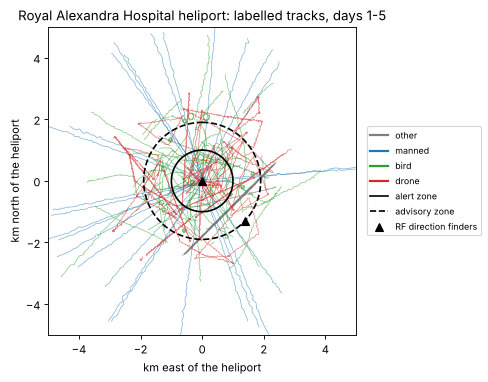

In [7]:
COLORS = {'other': 'tab:gray', 'manned': 'tab:blue', 'bird': 'tab:green', 'drone': 'tab:red'}
rows = tracks.merge(labels[['track_id', 'category']], on='track_id')  # labelled updates only
site = 'RAH'

fig, ax = plt.subplots(figsize=(6.5, 5))
for cat, color in COLORS.items():  # drones last, so they are drawn on top
    for _, t in rows[(rows.site_id == site) & (rows.category == cat)].groupby('track_id'):
        ax.plot(t.x_m / 1000, t.y_m / 1000, color=color, lw=0.6, alpha=0.6)
    ax.plot([], [], color=color, lw=2, label=cat)
angle = np.linspace(0, 2 * np.pi, 200)
for col, style, name in [('alert_radius_m', '-', 'alert zone'), ('advisory_radius_m', '--', 'advisory zone')]:
    r = sites.loc[site, col] / 1000
    ax.plot(r * np.sin(angle), r * np.cos(angle), color='black', ls=style, lw=1.5, label=name)
finders = sensors[(sensors.site_id == site) & (sensors.type == 'rf_direction_finder')]
fx, fy = to_xy(finders.lat, finders.lon, sites.loc[site, 'lat'], sites.loc[site, 'lon'])
ax.plot(fx / 1000, fy / 1000, 'k^', ms=8, ls='none', label='RF direction finders')
ax.set(xlim=(-5, 5), ylim=(-5, 5), aspect='equal', xlabel='km east of the heliport', ylabel='km north of the heliport',
       title='Royal Alexandra Hospital heliport: labelled tracks, days 1-5')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.show()

Road traffic draws straight lines along the road, helicopters fly in to the pad, birds wander, and drones fly out from wherever the pilot stands. A few drones cross into the alert zone: those are the ones task 2B is about.

Next, two features by category. Drones and birds overlap in echo size, but propellers spin much faster than wings beat, so wherever micro-Doppler is measured it separates them well.

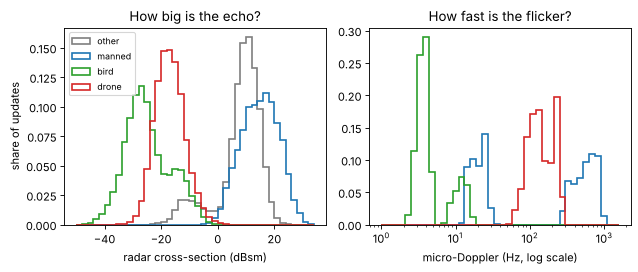

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for cat, color in COLORS.items():
    r = rows[rows.category == cat]
    for ax, values, bins in [(axes[0], r.rcs_dbsm, np.arange(-50, 36, 2)),
                             (axes[1], r.doppler_mod_hz.dropna(), np.logspace(0, 3.2, 41))]:
        ax.hist(values, bins=bins, weights=np.full(len(values), 1 / max(len(values), 1)),
                histtype='step', lw=1.5, color=color, label=cat)
axes[0].set(xlabel='radar cross-section (dBsm)', ylabel='share of updates', title='How big is the echo?')
axes[1].set(xscale='log', xlabel='micro-Doppler (Hz, log scale)', title='How fast is the flicker?')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. A validation split

To get an honest score before you submit, hold out the last labelled day (2025-09-19 06:00 UTC to 2025-09-20 06:00 UTC, midnight to midnight in Edmonton), learn from the four days before it, and score on the held-out day. This mirrors the test, which is also "the days after the training data".

In [9]:
val_start = pd.Timestamp('2025-09-19T06:00:00Z')
is_val = labels.start >= val_start
fit_ids = labels.track_id[~is_val].tolist()
val_ids = labels.track_id[is_val].tolist()
val_labels = labels[is_val]
print(f'learn from {len(fit_ids)} tracks, check on {len(val_ids)} tracks')
print('validation day:', val_labels.category.value_counts().to_dict())

os.makedirs('work', exist_ok=True)
val_labels.to_csv('work/val_labels.csv', index=False)  # for scoring from a terminal

learn from 843 tracks, check on 194 tracks
validation day: {'bird': 66, 'other': 63, 'manned': 41, 'drone': 24}


## 5. A simple baseline

Three small pieces, one per task. None of them is clever; they show the whole path from raw data to a scored submission, and every step is easy to inspect and improve.

### 5a. One row of features per track

A track has many rows, but the model needs one row per track. We summarise each track: speed, altitude and echo-size statistics, how often micro-Doppler, RF, ADS-B, sound and the camera saw it, the camera's most common label and its confidence, and how long the track lasted.

In [10]:
tracks['has_doppler'] = tracks.doppler_mod_hz.notna()
tracks['has_acoustic'] = tracks.acoustic_dba.notna()
tracks['has_camera'] = tracks.eo_label.notna()
tracks['hovering'] = tracks.speed_mps < 2

feat = tracks.groupby('track_id').agg(
    site_id=('site_id', 'first'), start=('timestamp', 'min'), end=('timestamp', 'max'), n_updates=('timestamp', 'size'),
    speed_mean=('speed_mps', 'mean'), speed_max=('speed_mps', 'max'), speed_std=('speed_mps', 'std'),
    hover_share=('hovering', 'mean'), alt_mean=('alt_m', 'mean'), alt_max=('alt_m', 'max'), alt_std=('alt_m', 'std'),
    rcs_mean=('rcs_dbsm', 'mean'), rcs_std=('rcs_dbsm', 'std'),
    doppler_share=('has_doppler', 'mean'), doppler_median=('doppler_mod_hz', 'median'),
    rf_share=('rf_detected', 'mean'), adsb_share=('adsb', 'mean'),
    acoustic_share=('has_acoustic', 'mean'), acoustic_max=('acoustic_dba', 'max'),
    camera_share=('has_camera', 'mean'), in_alert_zone=('in_alert_zone', 'any'))
feat['duration_s'] = (feat.end - feat.start).dt.total_seconds()

# the camera's most common label for each track, and its mean confidence
cam = tracks.dropna(subset=['eo_label']).groupby(['track_id', 'eo_label']).eo_conf.agg(['size', 'mean']).reset_index()
cam = cam.sort_values(['track_id', 'size', 'mean'], ascending=[True, False, False]).drop_duplicates('track_id').set_index('track_id')
feat['camera_label'] = cam.eo_label.reindex(feat.index).fillna('none')
feat['camera_conf'] = cam['mean'].reindex(feat.index).fillna(0.0)
feat.head()

,site_id,start,end,n_updates,speed_mean,speed_max,speed_std,hover_share,alt_mean,alt_max,alt_std,rcs_mean,rcs_std,doppler_share,doppler_median,rf_share,adsb_share,acoustic_share,acoustic_max,camera_share,in_alert_zone,duration_s,camera_label,camera_conf
track_id,,,,,,,,,,,,,,,,,,,,,,,,
GEN-00001,GEN,2025-09-22 00:32:00+00:00,2025-09-22 00:36:20+00:00,129,13.381395,21.8,9.267524,0.317829,87.446512,152.7,34.294403,-10.020930,3.465041,0.364341,62.8,0.945736,0.0,0.093023,41.3,0.534884,True,260.0,drone,0.710508
GEN-00002,GEN,2025-09-21 13:39:28+00:00,2025-09-21 13:40:16+00:00,12,24.100000,24.3,0.195402,0.000000,-3.125000,14.6,16.807797,12.675000,4.599432,0.000000,NaN,0.000000,0.0,0.000000,NaN,0.166667,False,48.0,vehicle,0.910000
GEN-00003,GEN,2025-09-16 15:06:18+00:00,2025-09-16 15:07:18+00:00,30,8.016667,9.8,1.258100,0.000000,63.010000,95.0,13.638924,-31.680000,3.122157,0.600000,3.8,0.000000,0.0,0.000000,NaN,1.000000,True,60.0,bird,0.712000
GEN-00004,GEN,2025-09-21 01:57:14+00:00,2025-09-21 01:59:58+00:00,83,8.507229,9.8,0.412838,0.000000,89.781928,120.1,9.730956,-22.222892,2.868599,0.000000,NaN,0.000000,0.0,0.000000,NaN,1.000000,True,164.0,bird,0.730882
GEN-00005,GEN,2025-09-16 23:31:42+00:00,2025-09-16 23:32:52+00:00,17,23.994118,24.4,0.343640,0.000000,-1.841176,44.3,29.085414,5.894118,2.801221,0.000000,NaN,0.000000,0.0,0.000000,NaN,0.058824,False,70.0,vehicle,0.780000


### 5b. What is it? A random forest

A random forest is a crowd of decision trees that vote. It copes with features on very different scales and works reasonably well without tuning. Blank values need a stand-in first: −1 for "no micro-Doppler measured" and 0 for "never heard".

In [11]:
NUMERIC = ['n_updates', 'duration_s', 'speed_mean', 'speed_max', 'speed_std', 'hover_share', 'alt_mean', 'alt_max', 'alt_std',
           'rcs_mean', 'rcs_std', 'doppler_share', 'doppler_median', 'rf_share', 'adsb_share', 'acoustic_share',
           'acoustic_max', 'camera_share', 'camera_conf']
CAMERA_LABELS = ['drone', 'bird', 'aircraft', 'vehicle', 'unknown', 'none']

def model_matrix(F):
    X = F[NUMERIC].copy()
    X['doppler_median'] = X.doppler_median.fillna(-1)
    X['acoustic_max'] = X.acoustic_max.fillna(0)
    for name in CAMERA_LABELS:
        X['camera_' + name] = (F.camera_label == name).astype(int)
    return X

X = model_matrix(feat)
y = labels.set_index('track_id').category

model = RandomForestClassifier(n_estimators=300, random_state=0)
model.fit(X.loc[fit_ids], y.loc[fit_ids])
print('most useful features:')
pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(8).round(3)

most useful features:


rcs_mean          0.157
speed_max         0.127
alt_mean          0.124
speed_mean        0.121
alt_std           0.076
alt_max           0.072
speed_std         0.056
doppler_median    0.045
dtype: float64

### 5c. Raise the alarm? A rule

Alert when (1) the model says drone, (2) at least one radar position is inside the site's alert circle, and (3) no flight authorization covers it. An authorization covers a track if, while the track is inside the zone, it is at the same site, inside the authorized time window and inside the authorized area.

In [12]:
inside = tracks.loc[tracks.in_alert_zone, ['track_id', 'site_id', 'timestamp', 'lat', 'lon']].merge(auths, on='site_id')
dx, dy = to_xy(inside.lat, inside.lon, inside.area_center_lat, inside.area_center_lon)
covered = inside.timestamp.between(inside.start_utc, inside.end_utc) & (np.hypot(dx, dy) <= inside.area_radius_m)
feat['authorized_flight'] = feat.index.isin(inside.track_id[covered])
print(f'{feat.in_alert_zone.sum()} tracks of all kinds have a position inside an alert zone; '
      f'{feat.authorized_flight.sum()} of them were there during an authorized flight')
auths.head(3)

860 tracks of all kinds have a position inside an alert zone; 23 of them were there during an authorized flight


,site_id,operator,purpose,start_utc,end_utc,area_center_lat,area_center_lon,area_radius_m,max_alt_m,rf_band_ghz,operator_lat,operator_lon
0,YEG,Licensed operator (fictional),wildlife survey,2025-09-16 18:38:00+00:00,2025-09-16 19:18:44+00:00,53.3097,-113.58,3000,120,2.4,53.29638,-113.57625
1,YEG,Licensed operator (fictional),infrastructure inspection,2025-09-16 19:32:04+00:00,2025-09-16 20:18:14+00:00,53.3097,-113.58,3000,120,5.8,53.32197,-113.58711
2,YEG,Licensed operator (fictional),security patrol,2025-09-20 00:41:58+00:00,2025-09-20 01:28:27+00:00,53.3097,-113.58,3000,120,5.8,53.31199,-113.55766


### 5d. Find the pilot: cross the two bearings

Each direction finder gives a line on the map, starting at the sensor and pointing along the bearing it measured. The pilot is near where the two lines cross. For every update where both sensors heard the link, we find the point closest to both lines (a tiny least-squares problem). Then we take the median of those points over the track, so a few bad updates can't drag the answer away. Updates where the lines are nearly parallel, or cross behind a sensor, are skipped. Tracks without such updates get no estimate (a blank).

In [13]:
rf_finders = sensors[sensors.type == 'rf_direction_finder'].set_index('sensor_id')

def finder_xy(site_ids, name):
    """Position of each row's RF1 or RF2 finder, in metres from its site centre."""
    f = rf_finders.loc[site_ids + '-' + name]
    x, y = to_xy(f.lat.values, f.lon.values, sites.loc[site_ids, 'lat'].values, sites.loc[site_ids, 'lon'].values)
    return np.column_stack([x, y])

def direction(bearing_deg):
    b = np.radians(np.asarray(bearing_deg, dtype=float))
    return np.column_stack([np.sin(b), np.cos(b)])  # (east, north)

def crossing_points(rows):
    """Least-squares crossing point of the RF1 and RF2 bearing lines for each row, in metres from the site."""
    p1, p2 = finder_xy(rows.site_id, 'RF1'), finder_xy(rows.site_id, 'RF2')
    d1, d2 = direction(rows.rf1_bearing_deg), direction(rows.rf2_bearing_deg)
    A1 = np.eye(2) - d1[:, :, None] * d1[:, None, :]  # keeps only the part of a vector across line 1
    A2 = np.eye(2) - d2[:, :, None] * d2[:, None, :]
    A, b = A1 + A2, (A1 @ p1[:, :, None] + A2 @ p2[:, :, None])[:, :, 0]
    xy = np.full_like(b, np.nan)
    ok = np.linalg.det(A) > np.sin(np.radians(2)) ** 2  # skip nearly parallel lines
    xy[ok] = np.linalg.solve(A[ok], b[ok][:, :, None])[:, :, 0]
    ahead = (((xy - p1) * d1).sum(axis=1) > 0) & (((xy - p2) * d2).sum(axis=1) > 0)
    xy[~ahead] = np.nan
    return xy

both = tracks[tracks.rf1_bearing_deg.notna() & tracks.rf2_bearing_deg.notna()].copy()
xy = crossing_points(both)
both['fix_x'], both['fix_y'] = xy[:, 0], xy[:, 1]
fix = both.dropna(subset=['fix_x']).groupby('track_id')[['fix_x', 'fix_y']].median()
site_of = feat.site_id.reindex(fix.index)
fix['operator_lat'], fix['operator_lon'] = to_latlon(fix.fix_x, fix.fix_y, site_of.map(sites.lat), site_of.map(sites.lon))
print(f"{tracks.loc[tracks.rf_detected == 1, 'track_id'].nunique()} tracks have a controller link; "
      f"{len(fix)} of them get a pilot estimate")

121 tracks have a controller link; 108 of them get a pilot estimate


Finally, a helper that puts the three answers into the submission format.

In [14]:
def make_submission(ids, predicted_category):
    ids = list(ids)
    F = feat.loc[ids]
    sub = pd.DataFrame({'track_id': ids, 'category': predicted_category})
    sub['alert'] = ((sub.category.values == 'drone') & F.in_alert_zone.values & ~F.authorized_flight.values).astype(int)
    est = fix.reindex(ids)
    sub['operator_lat'] = est.operator_lat.round(6).values
    sub['operator_lon'] = est.operator_lon.round(6).values
    return sub

## 6. Score on the validation day

In [15]:
val_sub = make_submission(val_ids, model.predict(X.loc[val_ids]))
val_sub.to_csv('work/val_predictions.csv', index=False)

result = score_tracks(val_sub, val_labels)
result['summary']

{'2A_macro_f1': 1.0, '2B_alert_f1': 1.0, '2C_median_error_m': 884.4}

In [16]:
# 2A: per-class table
pd.DataFrame(result['task_2A_category']['per_class']).T.astype({'support': int, 'predicted': int})

,precision,recall,f1,support,predicted
drone,1.0,1.0,1.0,24,24
bird,1.0,1.0,1.0,66,66
manned,1.0,1.0,1.0,41,41
other,1.0,1.0,1.0,63,63


In [17]:
# 2A: confusion matrix, rows = truth, columns = prediction
pd.DataFrame(result['task_2A_category']['confusion_matrix_rows_true_cols_predicted']).T

,drone,bird,manned,other
drone,24,0,0,0
bird,0,66,0,0
manned,0,0,41,0
other,0,0,0,63


In [18]:
print('2B raise the alarm:', result['task_2B_alert'])
print('2C find the pilot: ', result['task_2C_operator'])

2B raise the alarm: {'f1': 1.0, 'precision': 1.0, 'recall': 1.0, 'true_alerts': 6, 'predicted_alerts': 6, 'true_positives': 6, 'false_positives': 0, 'missed': 0}
2C find the pilot:  {'median_error_m': 884.4, 'share_within_300m': 0.4583, 'scored_tracks': 24, 'tracks_with_estimate': 20, 'median_error_m_where_estimated': 221.8}


The same scoring from a terminal:

```
python score.py --submission work/val_predictions.csv --labels work/val_labels.csv
```

Read these numbers with care. The validation day holds only about 20 drones and a handful of true alerts, so a single mistake moves the 2B and 2C scores a lot. For 2C, compare `median_error_m` with `median_error_m_where_estimated`: the gap is the price of the drones that got no estimate at all (each counted as 5,000 m). The ideas below suggest ways to close it.

## 7. Learn from all five days and write the submission

Now refit the model on every labelled track and answer for the test tracks.

In [19]:
all_ids = labels.track_id.tolist()
model.fit(X.loc[all_ids], y.loc[all_ids])
test_sub = make_submission(test_ids, model.predict(X.loc[test_ids]))
assert set(test_sub.track_id) == set(test_ids)

os.makedirs('submissions', exist_ok=True)
test_sub.to_csv('submissions/tracks.csv', index=False)
print(f'wrote submissions/tracks.csv: {len(test_sub)} tracks, {test_sub.alert.sum()} alerts, '
      f'{test_sub.operator_lat.notna().sum()} pilot estimates')
print(test_sub.category.value_counts().to_dict())
test_sub.head()

wrote submissions/tracks.csv: 419 tracks, 15 alerts, 33 pilot estimates
{'other': 148, 'bird': 139, 'manned': 88, 'drone': 44}


,track_id,category,alert,operator_lat,operator_lon
0,GEN-00001,drone,1,53.347479,-114.280958
1,GEN-00002,other,0,NaN,NaN
2,GEN-00004,bird,0,NaN,NaN
3,GEN-00006,bird,0,NaN,NaN
4,GEN-00007,bird,0,NaN,NaN


## 8. Ideas to go further

- **Join the pieces of a flight.** One flight often shows up as several tracks a few seconds apart. Linking them lets a confident label, an alert or a pilot estimate carry over to the short pieces.
- **Use the launch point.** Pilots usually stand near where the drone took off. The low, slow start (or end) of a drone flight is a strong hint, and the only one for drones that fly without a radio link.
- **One bearing is still useful.** Often only one direction finder hears the link. Signal strength (`rf_rssi_dbm`) falls with distance, so one bearing plus signal strength can still give a rough position.
- **Fuse bearings more carefully.** Weight each update by how sharply the two lines cross, drop outliers, and combine all the pieces of a flight.
- **A fairer zone test.** Radar positions are noisy: ask for more than one update inside the circle, or a small margin, before alerting. Also compare the authorization's RF band and registered operator position, not just time and area.
- **Richer track features.** Turn rate, time spent hovering, the climb profile, distance to the site, camera votes weighted by confidence and by time of day (the camera is less reliable at night).
- **Expect the unexpected.** Real skies hold things a training set never showed you. Decide what your model should do with a track that looks like none of the four classes.